In [1]:
import os

# Chargement des données : sur Google Colab, on propose l'upload si les fichiers
# ne sont pas déjà présents ; en local (ou sur GitHub), les CSV sont supposés être
# à côté du notebook (voir data/README.md).
try:
    import google.colab  # noqa: F401
    from google.colab import files
    if not (os.path.exists('airbnb_train.csv') and os.path.exists('airbnb_test.csv')):
        uploaded = files.upload()
except ImportError:
    pass


# Projet Airbnb — Analyse exploratoire des données

## Réalisé par

- Youssef AMOR
- Abdessamad AIT HAKI

## Introduction

L’objectif de ce projet est de prédire le logarithme du prix (`log_price`) d’un logement Airbnb à partir de différentes caractéristiques :
- localisation
- équipements
- type de logement
- informations sur l’hôte
- description textuelle

Avant de construire des modèles de machine learning, il est important de comprendre les données :
- structure du dataset
- valeurs manquantes
- distribution des variables
- corrélations
- relations entre les variables et le prix

Cette première partie est consacrée à l’exploration des données.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

# Lecture des datasets

Le dataset train contient :
- les caractéristiques des logements
- la variable cible `log_price`

Le dataset test contient uniquement les caractéristiques.

In [3]:
train = pd.read_csv('../data/airbnb_train.csv.gz')
test = pd.read_csv('../data/airbnb_test.csv.gz')

# Le CSV de test n'a pas d'en-tête pour sa première colonne : pandas la nomme
# automatiquement "Unnamed: 0". On la renomme en 'id' car il s'agit bien de
# l'identifiant du logement, nécessaire pour construire le fichier de soumission.
test = test.rename(columns={'Unnamed: 0': 'id'})


In [4]:
train.shape

(22234, 28)

In [5]:
test.shape

(51877, 27)

# Aperçu du dataset

Nous affichons les premières lignes du dataset afin de comprendre la structure des données.

In [6]:
train.head()

         id  log_price property_type        room_type  \
0   5708593   4.317488         House     Private room   
1  14483613   4.007333         House     Private room   
2  10412649   7.090077     Apartment  Entire home/apt   
3  17954362   3.555348         House     Private room   
4   9969781   5.480639         House  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {TV,"Wireless Internet",Kitchen,"Free parking ...             3        1.0   
1  {"Wireless Internet","Air conditioning",Kitche...             4        2.0   
2  {TV,"Wireless Internet","Air conditioning",Kit...             6        2.0   
3  {TV,"Cable TV",Internet,"Wireless Internet","A...             1        1.0   
4  {TV,"Cable TV",Internet,"Wireless Internet",Ki...             4        1.0   

   bed_type cancellation_policy  cleaning_fee city  \
0  Real Bed            flexible         False   LA   
1  Real Bed              strict         False  NYC   
2  Real 

In [7]:
train.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='str')

# Types des variables

Nous allons maintenant observer les types des colonnes :
- numériques
- catégorielles
- textuelles
- booléennes

In [8]:
train.dtypes

id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

# Analyse des valeurs manquantes

Les valeurs manquantes sont très importantes en machine learning.

Certaines variables peuvent contenir beaucoup de NaN :
- description
- review_scores_rating
- first_review
- host_response_rate

Nous allons mesurer leur quantité.

In [9]:
missing_values = train.isnull().sum()
missing_values = missing_values.sort_values(ascending=False)

missing_values

host_response_rate        5475
review_scores_rating      4978
first_review              4725
last_review               4716
neighbourhood             2086
zipcode                    303
host_has_profile_pic        56
host_identity_verified      56
host_since                  56
bathrooms                   51
beds                        35
bedrooms                    26
description                  0
city                         0
cleaning_fee                 0
cancellation_policy          0
bed_type                     0
accommodates                 0
amenities                    0
room_type                    0
log_price                    0
property_type                0
id                           0
instant_bookable             0
latitude                     0
number_of_reviews            0
longitude                    0
name                         0
dtype: int64

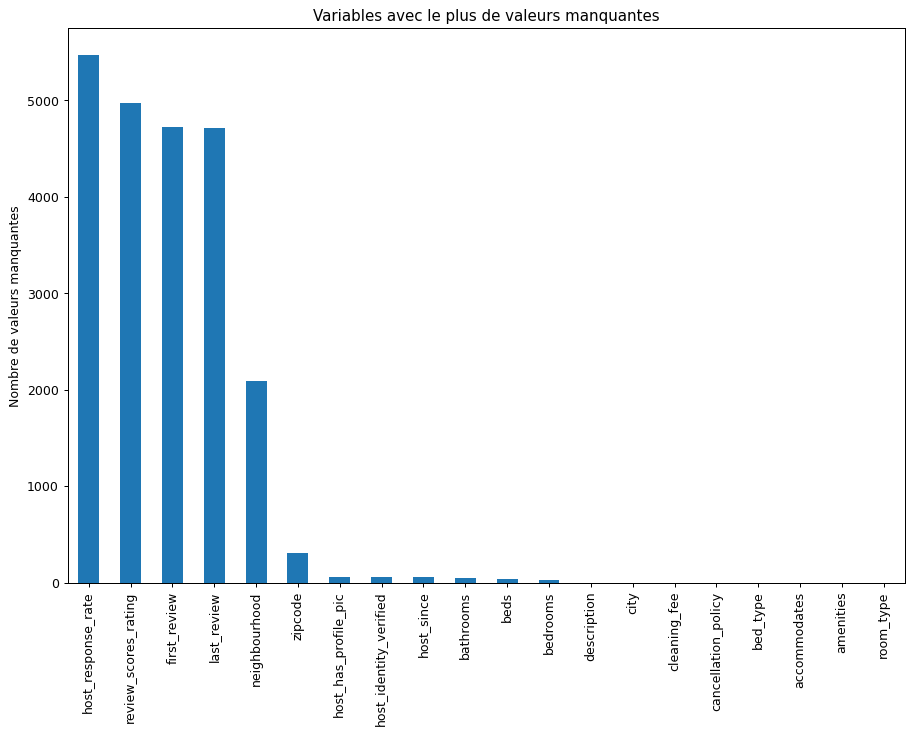

In [10]:
plt.figure(figsize=(12,8))

missing_values.head(20).plot(kind='bar')

plt.title('Variables avec le plus de valeurs manquantes')

plt.ylabel('Nombre de valeurs manquantes')

plt.show()

# Analyse de la variable cible

La variable à prédire est `log_price`.

Nous allons observer :
- sa distribution
- sa moyenne
- ses valeurs extrêmes

In [11]:
train['log_price'].describe()

count    22234.000000
mean         4.783481
std          0.718758
min          2.302585
25%          4.317488
50%          4.700480
75%          5.220356
max          7.600402
Name: log_price, dtype: float64

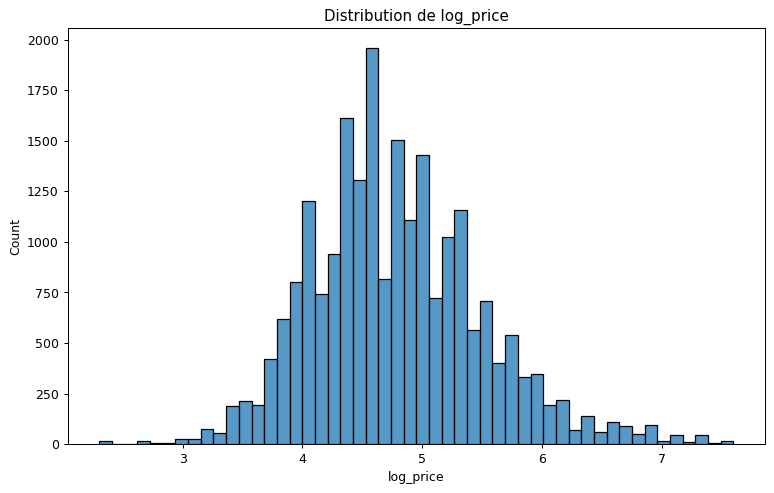

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(train['log_price'], bins=50)

plt.title('Distribution de log_price')

plt.xlabel('log_price')

plt.show()

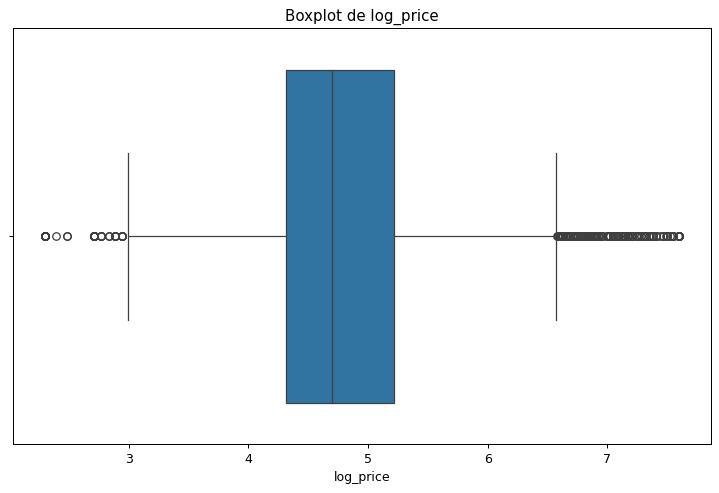

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(x=train['log_price'])

plt.title('Boxplot de log_price')

plt.show()

# Analyse des variables numériques

Nous allons étudier plusieurs variables numériques importantes :
- accommodates
- bathrooms
- bedrooms
- beds
- number_of_reviews
- review_scores_rating

In [14]:
num_cols = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating',
    'latitude',
    'longitude'
]

train[num_cols].describe()

       accommodates     bathrooms      bedrooms          beds  \
count  22234.000000  22183.000000  22208.000000  22199.000000   
mean       3.155573      1.236037      1.264769      1.711473   
std        2.143870      0.586246      0.852819      1.254903   
min        1.000000      0.000000      0.000000      0.000000   
25%        2.000000      1.000000      1.000000      1.000000   
50%        2.000000      1.000000      1.000000      1.000000   
75%        4.000000      1.000000      1.000000      2.000000   
max       16.000000      8.000000     10.000000     18.000000   

       number_of_reviews  review_scores_rating      latitude     longitude  
count       22234.000000          17256.000000  22234.000000  22234.000000  
mean           20.670774             94.069077     38.462971    -92.269305  
std            37.183731              7.782235      3.071679     21.670081  
min             0.000000             20.000000     33.339002   -122.510940  
25%             1.000000     

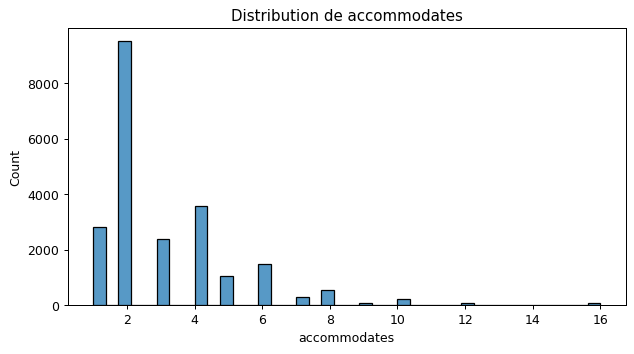

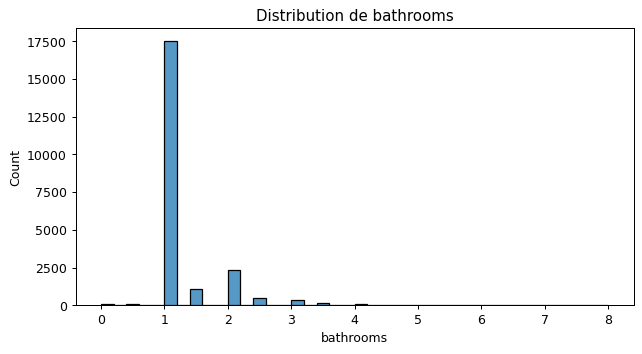

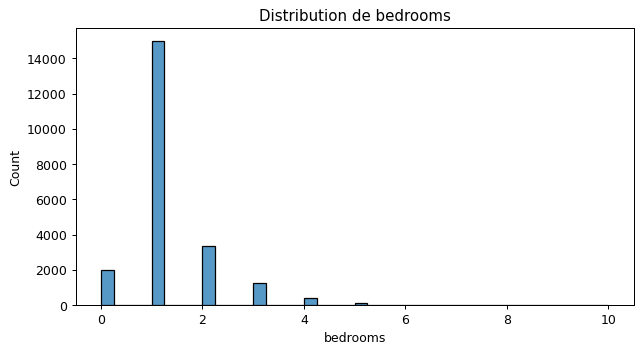

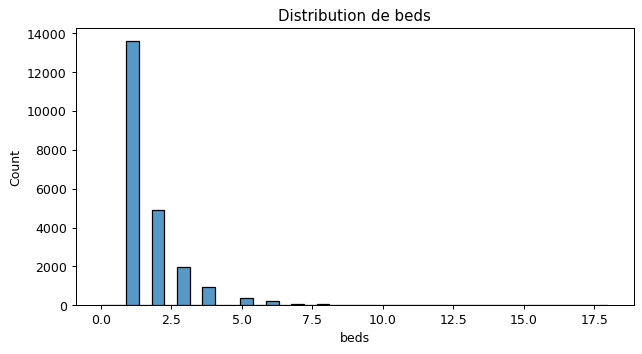

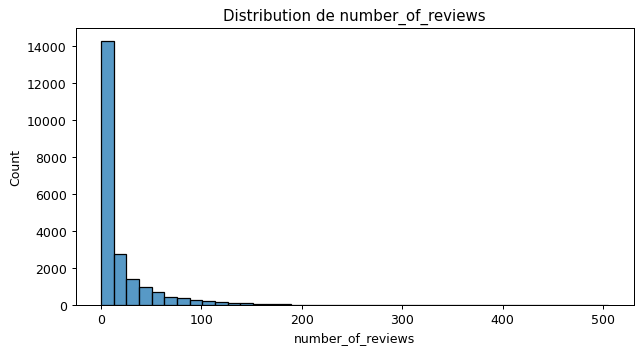

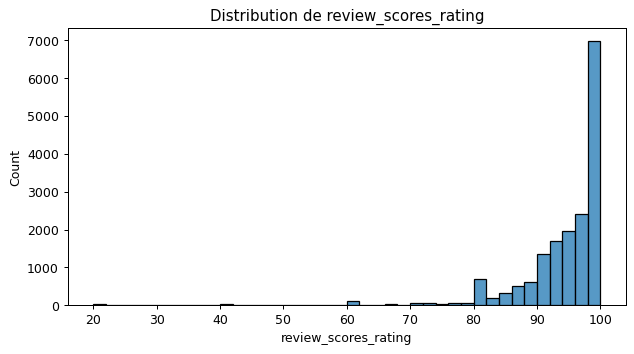

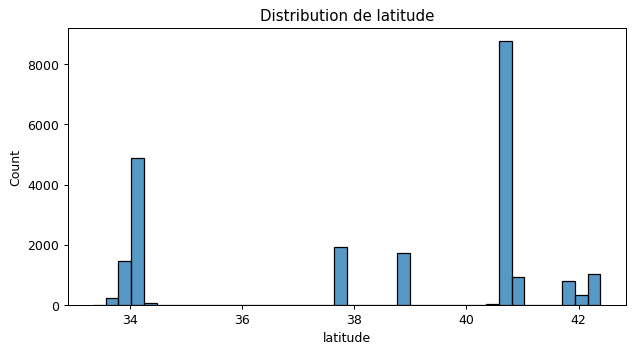

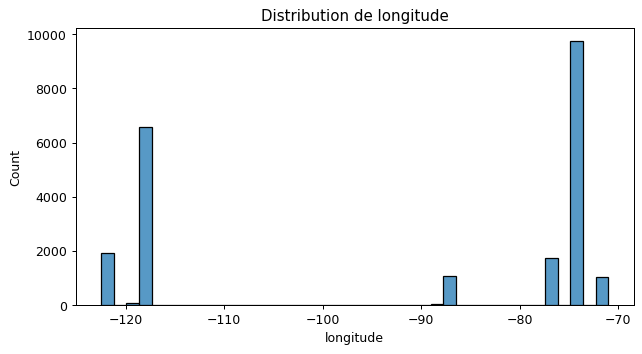

In [15]:
for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(train[col], bins=40)

    plt.title(f'Distribution de {col}')

    plt.show()

# Corrélations avec le prix

Nous allons analyser la relation entre les variables numériques et le prix.

In [16]:
corr = train[num_cols + ['log_price']].corr()

corr['log_price'].sort_values(ascending=False)

log_price               1.000000
accommodates            0.564874
bedrooms                0.472871
beds                    0.435212
bathrooms               0.369118
review_scores_rating    0.092342
latitude                0.005231
number_of_reviews      -0.039138
longitude              -0.045348
Name: log_price, dtype: float64

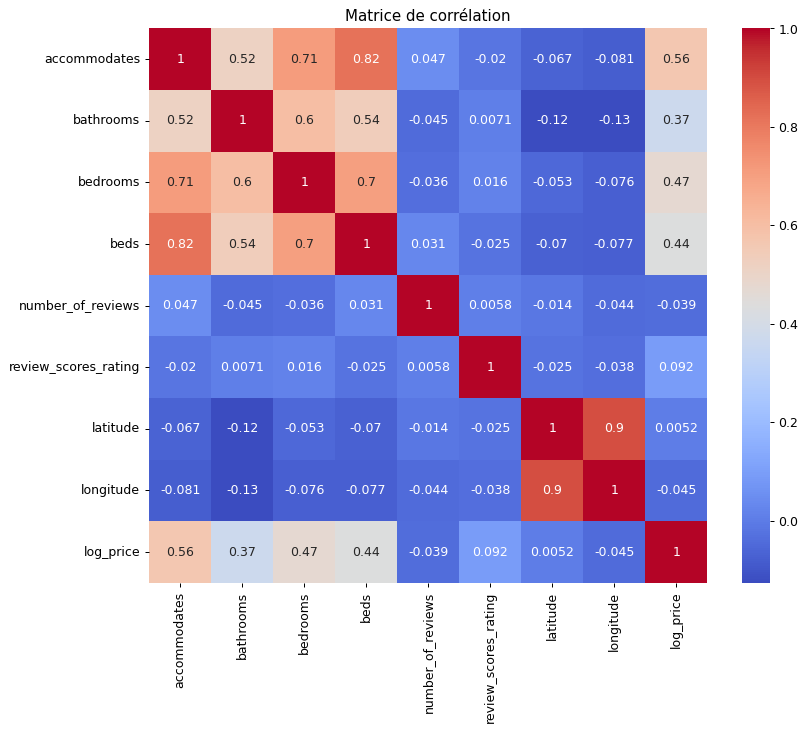

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Matrice de corrélation')

plt.show()

# Analyse de accommodates

La variable `accommodates` représente le nombre de personnes pouvant être hébergées.

On peut supposer qu’un logement accueillant plus de personnes coûte plus cher.

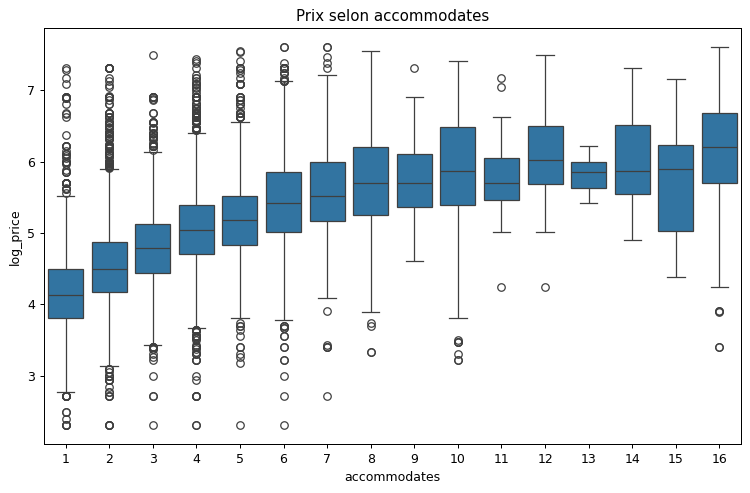

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=train['accommodates'],
    y=train['log_price']
)

plt.title('Prix selon accommodates')

plt.show()

# Analyse de room_type

Le type de chambre est probablement une variable très importante.

In [19]:
train['room_type'].value_counts()

room_type
Entire home/apt    12348
Private room        9219
Shared room          667
Name: count, dtype: int64

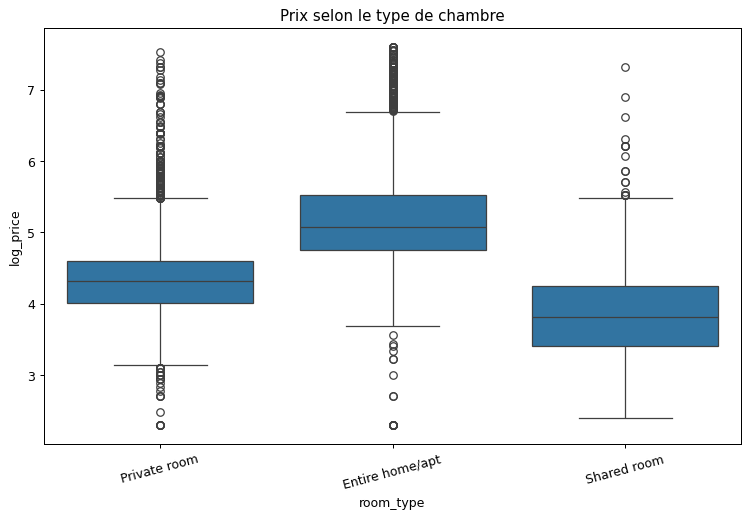

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=train['room_type'],
    y=train['log_price']
)

plt.title('Prix selon le type de chambre')

plt.xticks(rotation=15)

plt.show()

# Analyse de property_type

Nous allons étudier les différents types de logements :
- Apartment
- House
- Loft
- Condominium
- etc.

In [21]:
train['property_type'].value_counts().head(15)

property_type
Apartment          14635
House               4965
Condominium          836
Townhouse            507
Loft                 381
Other                200
Guesthouse           156
Bed & Breakfast      130
Bungalow              90
Villa                 54
Dorm                  43
Guest suite           39
Timeshare             29
Boat                  26
Boutique hotel        25
Name: count, dtype: int64

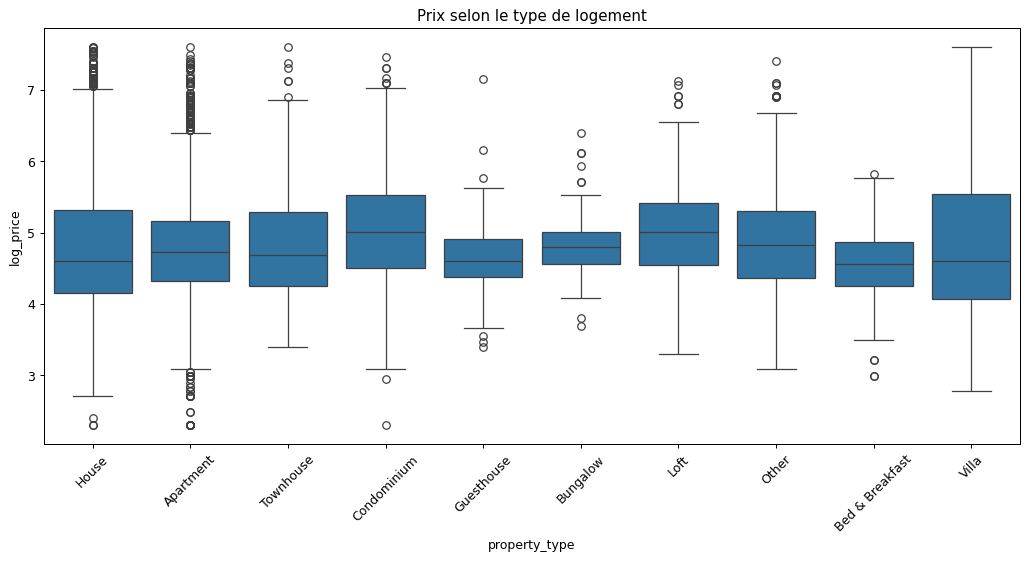

In [22]:
plt.figure(figsize=(14,6))

top_property = train['property_type'].value_counts().head(10).index

sns.boxplot(
    data=train[train['property_type'].isin(top_property)],
    x='property_type',
    y='log_price'
)

plt.xticks(rotation=45)

plt.title('Prix selon le type de logement')

plt.show()

# Analyse géographique

La position géographique influence fortement les prix Airbnb.

Nous allons afficher les logements selon :
- leur longitude
- leur latitude

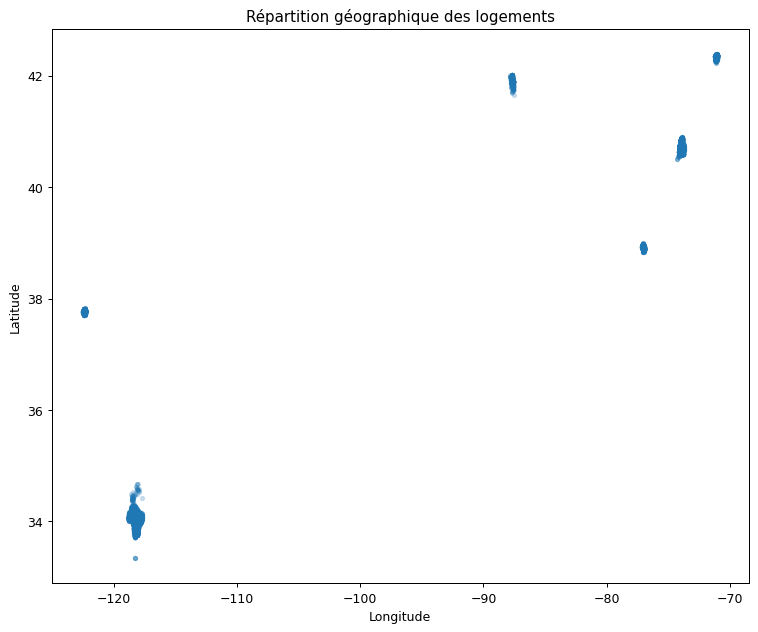

In [23]:
plt.figure(figsize=(10,8))

plt.scatter(
    train['longitude'],
    train['latitude'],
    alpha=0.2,
    s=10
)

plt.title('Répartition géographique des logements')

plt.xlabel('Longitude')

plt.ylabel('Latitude')

plt.show()

# Carte des prix

Nous allons colorer les logements selon leur prix.

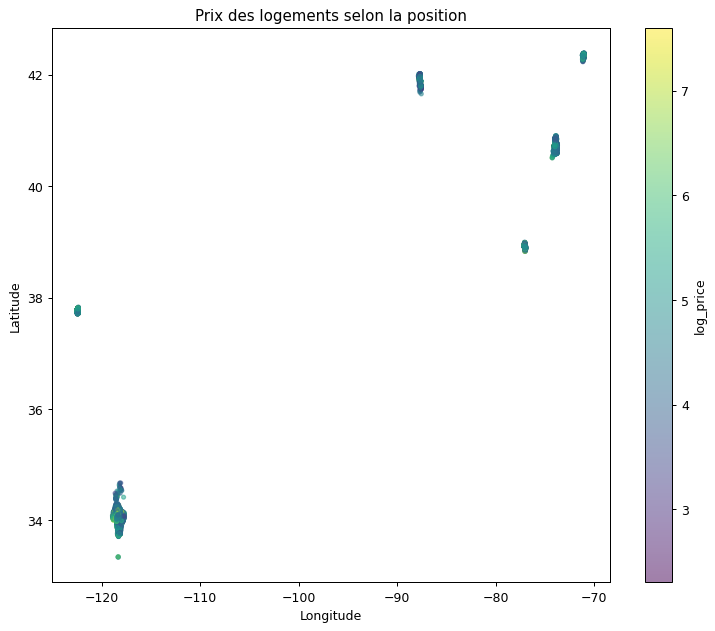

In [24]:
plt.figure(figsize=(10,8))

plt.scatter(
    train['longitude'],
    train['latitude'],
    c=train['log_price'],
    cmap='viridis',
    alpha=0.5,
    s=10
)

plt.colorbar(label='log_price')

plt.title('Prix des logements selon la position')

plt.xlabel('Longitude')

plt.ylabel('Latitude')

plt.show()

# Analyse des villes

Certaines villes sont probablement beaucoup plus chères que d’autres.

In [25]:
train['city'].value_counts()

city
NYC        9739
LA         6672
SF         1924
DC         1744
Chicago    1127
Boston     1028
Name: count, dtype: int64

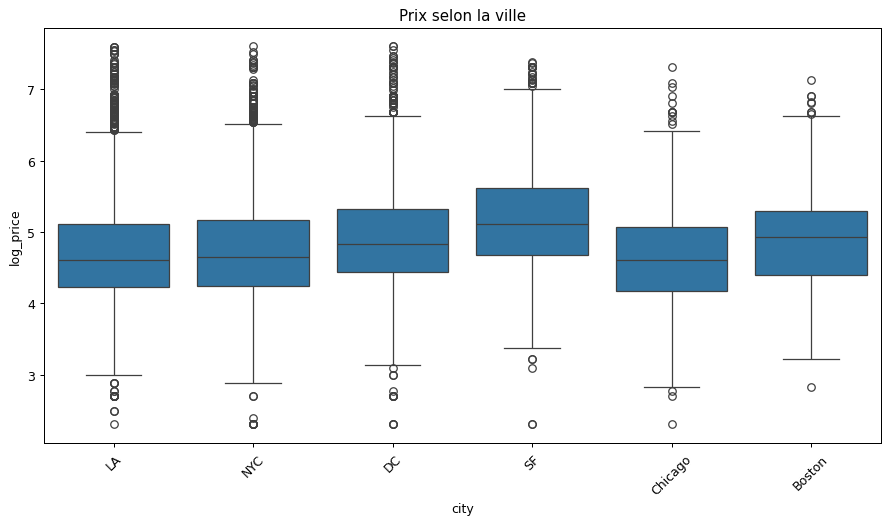

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=train,
    x='city',
    y='log_price'
)

plt.xticks(rotation=45)

plt.title('Prix selon la ville')

plt.show()

# Analyse des équipements

La colonne `amenities` contient les équipements du logement sous forme textuelle.

Exemple :
- Wifi
- TV
- Kitchen
- Air conditioning

Nous allons créer de nouvelles variables.

In [27]:
train['amenities'].head()

0    {TV,"Wireless Internet",Kitchen,"Free parking ...
1    {"Wireless Internet","Air conditioning",Kitche...
2    {TV,"Wireless Internet","Air conditioning",Kit...
3    {TV,"Cable TV",Internet,"Wireless Internet","A...
4    {TV,"Cable TV",Internet,"Wireless Internet",Ki...
Name: amenities, dtype: str

In [28]:
train['amenities_count'] = train['amenities'].str.count(',')

test['amenities_count'] = test['amenities'].str.count(',')

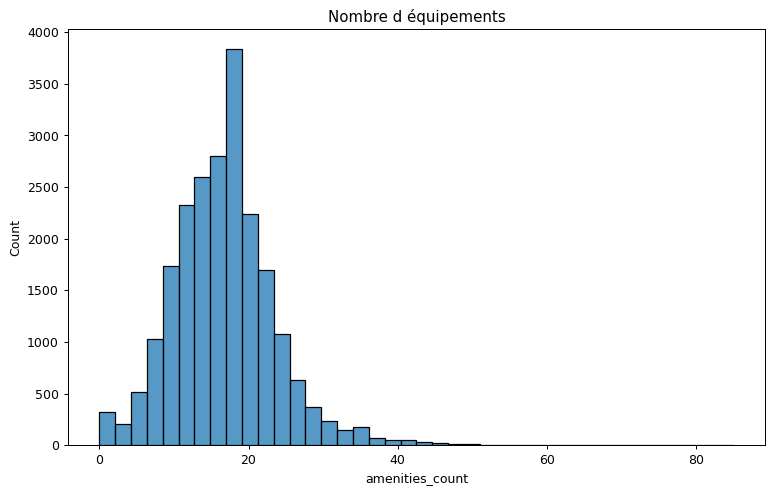

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(train['amenities_count'], bins=40)

plt.title('Nombre d équipements')

plt.show()

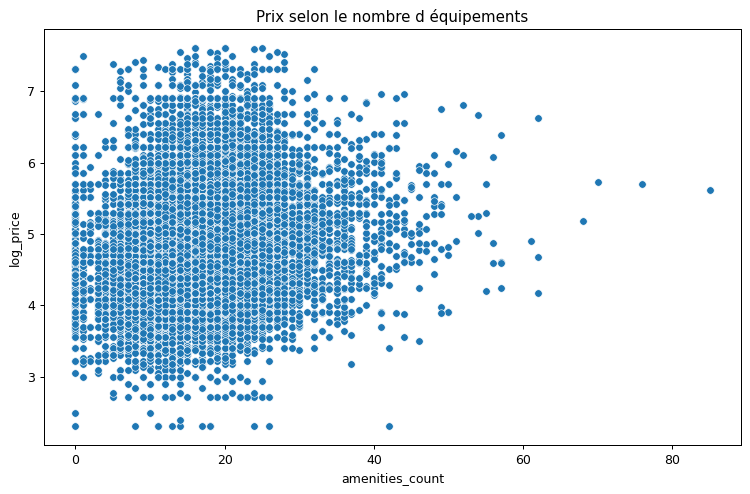

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=train['amenities_count'],
    y=train['log_price']
)

plt.title('Prix selon le nombre d équipements')

plt.show()

# Création de variables à partir des équipements

Nous allons détecter automatiquement certains équipements importants.

In [31]:
important_amenities = [
    'Wifi',
    'TV',
    'Kitchen',
    'Heating',
    'Air conditioning',
    'Washer',
    'Dryer'
]

In [32]:
for amenity in important_amenities:

    col_name = amenity.lower().replace(' ', '_')

    train[col_name] = train['amenities'].str.contains(
        amenity,
        case=False,
        na=False
    ).astype(int)

    test[col_name] = test['amenities'].str.contains(
        amenity,
        case=False,
        na=False
    ).astype(int)

In [33]:
train[
    [
        'wifi',
        'tv',
        'kitchen',
        'heating'
    ]
].head()

   wifi  tv  kitchen  heating
0     0   1        1        0
1     0   0        1        1
2     0   1        1        1
3     0   1        1        1
4     0   1        1        1

# Feature Engineering

Le feature engineering consiste à transformer les données brutes en variables plus utiles pour les modèles de machine learning.

Cette étape est essentielle pour améliorer les performances des modèles.

Nous allons travailler sur :
- les variables booléennes
- les équipements
- les dates
- les textes
- les variables catégorielles

In [34]:
train.head(2)

         id  log_price property_type     room_type  \
0   5708593   4.317488         House  Private room   
1  14483613   4.007333         House  Private room   

                                           amenities  accommodates  bathrooms  \
0  {TV,"Wireless Internet",Kitchen,"Free parking ...             3        1.0   
1  {"Wireless Internet","Air conditioning",Kitche...             4        2.0   

   bed_type cancellation_policy  cleaning_fee city  \
0  Real Bed            flexible         False   LA   
1  Real Bed              strict         False  NYC   

                                         description first_review  \
0  Large bright airy room with 2 balconies and Ja...          NaN   
1  Private room for rent in a six bedroom apt wit...   2017-05-07   

  host_has_profile_pic host_identity_verified host_response_rate  host_since  \
0                    t                      f                NaN  2015-12-12   
1                    t                      t               10

# Transformation des variables booléennes

Certaines colonnes contiennent des valeurs :
- t / f
- True / False

Nous allons les convertir en 0 et 1.

In [35]:
boolean_cols = [
    'cleaning_fee',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable'
]

In [36]:
for col in boolean_cols:

    train[col] = train[col].map({
        't':1,
        'f':0,
        True:1,
        False:0
    })

    test[col] = test[col].map({
        't':1,
        'f':0,
        True:1,
        False:0
    })

In [37]:
train[boolean_cols].head()

   cleaning_fee  host_has_profile_pic  host_identity_verified  \
0             0                   1.0                     0.0   
1             0                   1.0                     1.0   
2             0                   1.0                     0.0   
3             1                   1.0                     1.0   
4             1                   1.0                     1.0   

   instant_bookable  
0                 1  
1                 1  
2                 1  
3                 0  
4                 0  

# Transformation de host_response_rate

Cette variable contient des pourcentages sous forme de texte :
- 90%
- 100%
- 75%

Nous allons convertir cette colonne en valeur numérique.

In [38]:
train['host_response_rate'].head()

0     NaN
1    100%
2     NaN
3    100%
4    100%
Name: host_response_rate, dtype: str

In [39]:
train['host_response_rate'] = train['host_response_rate'].str.replace('%','')
test['host_response_rate'] = test['host_response_rate'].str.replace('%','')

In [40]:
train['host_response_rate'] = pd.to_numeric(
    train['host_response_rate'],
    errors='coerce'
)

test['host_response_rate'] = pd.to_numeric(
    test['host_response_rate'],
    errors='coerce'
)

In [41]:
train['host_response_rate'].describe()

count    16759.000000
mean        94.486425
std         16.059047
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

# Transformation des dates

Les dates contiennent beaucoup d’informations utiles.

Nous allons créer :
- ancienneté de l’hôte
- ancienneté des reviews
- nombre de jours depuis le dernier review

In [42]:
date_cols = [
    'host_since',
    'first_review',
    'last_review'
]

In [43]:
for col in date_cols:

    train[col] = pd.to_datetime(train[col], errors='coerce')
    test[col] = pd.to_datetime(test[col], errors='coerce')

In [44]:
today = pd.Timestamp.today()

In [45]:
train['host_days'] = (today - train['host_since']).dt.days
test['host_days'] = (today - test['host_since']).dt.days

In [46]:
train['days_since_last_review'] = (
    today - train['last_review']
).dt.days

test['days_since_last_review'] = (
    today - test['last_review']
).dt.days

In [47]:
train['days_since_first_review'] = (
    today - train['first_review']
).dt.days

test['days_since_first_review'] = (
    today - test['first_review']
).dt.days

In [48]:
train[
    [
        'host_days',
        'days_since_last_review',
        'days_since_first_review'
    ]
].head()

   host_days  days_since_last_review  days_since_first_review
0     3931.0                     NaN                      NaN
1     3603.0                  3286.0                   3419.0
2     3566.0                     NaN                      NaN
3     5156.0                  3274.0                   3631.0
4     4801.0                  3306.0                   3643.0

# Analyse des colonnes texte

Les colonnes texte contiennent beaucoup d’informations :
- description
- name

Nous allons créer :
- longueur du texte
- nombre de mots

In [49]:
text_cols = [
    'description',
    'name'
]

In [50]:
for col in text_cols:

    train[col] = train[col].fillna('')
    test[col] = test[col].fillna('')

In [51]:
train['description_length'] = train['description'].str.len()
test['description_length'] = test['description'].str.len()

In [52]:
train['name_length'] = train['name'].str.len()
test['name_length'] = test['name'].str.len()

In [53]:
train['description_words'] = train['description'].str.split().str.len()
test['description_words'] = test['description'].str.split().str.len()

In [54]:
train[
    [
        'description_length',
        'name_length',
        'description_words'
    ]
].head()

   description_length  name_length  description_words
0                 669           23                118
1                1000           50                184
2                 494           49                 90
3                1000           48                178
4                1000           29                172

# Corrélation des nouvelles features avec le prix

Nous allons regarder si les nouvelles variables semblent utiles pour prédire le prix.

In [55]:
new_num_cols = [
    'amenities_count',
    'host_response_rate',
    'host_days',
    'days_since_last_review',
    'days_since_first_review',
    'description_length',
    'name_length',
    'description_words'
]

In [56]:
corr_new = train[new_num_cols + ['log_price']].corr()

corr_new['log_price'].sort_values(ascending=False)

log_price                  1.000000
amenities_count            0.198436
days_since_first_review    0.079183
host_days                  0.072145
name_length                0.063846
description_length         0.047935
description_words          0.026684
days_since_last_review     0.021075
host_response_rate        -0.002562
Name: log_price, dtype: float64

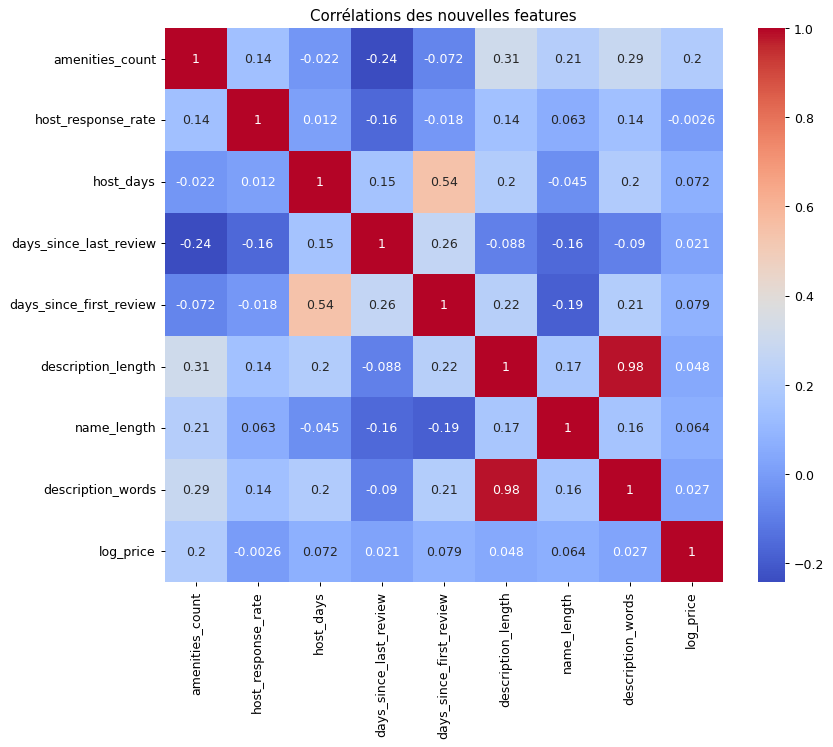

In [57]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_new,
    annot=True,
    cmap='coolwarm'
)

plt.title('Corrélations des nouvelles features')

plt.show()

# Préparation des données pour le machine learning

Nous allons maintenant :
- sélectionner les variables
- encoder les variables catégorielles
- préparer un dataset utilisable par sklearn

In [58]:
train.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds',
       'amenities_count', 'wifi', 'tv', 'kitchen', 'heating',
       'air_conditioning', 'washer', 'dryer', 'host_days',
       'days_since_last_review', 'days_since_first_review',
       'description_length', 'name_length', 'description_words'],
      dtype='str')

In [59]:
features = [

    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'latitude',
    'longitude',
    'number_of_reviews',
    'review_scores_rating',

    'cleaning_fee',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',

    'amenities_count',
    'host_response_rate',
    'host_days',
    'days_since_last_review',
    'days_since_first_review',

    'description_length',
    'name_length',
    'description_words',

    'wifi',
    'tv',
    'kitchen',
    'heating',

    'property_type',
    'room_type',
    'bed_type',
    'city',
    'cancellation_policy'
]

In [60]:
target = 'log_price'

In [61]:
X = train[features]
y = train[target]

X_test = test[features]

# Encodage des variables catégorielles

Les modèles de machine learning ne peuvent pas utiliser directement du texte.

Nous allons transformer les catégories avec One Hot Encoding.

In [62]:
X = pd.get_dummies(X, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)

In [63]:
X, X_test = X.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [64]:
X.shape

(22234, 69)

In [65]:
X = X.fillna(0)
X_test = X_test.fillna(0)

# Séparation train / validation

Nous allons garder une partie des données pour évaluer les modèles.

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
X_train.shape

(17787, 69)

# Baseline — Régression Linéaire

Nous allons commencer par un modèle très simple :
la régression linéaire.

Ce modèle servira de baseline afin de comparer les modèles plus avancés.

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [70]:
linear_model = LinearRegression()

In [71]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [72]:
linear_preds = linear_model.predict(X_valid)

In [73]:
linear_rmse = np.sqrt(
    mean_squared_error(y_valid, linear_preds)
)

linear_rmse

np.float64(0.46033359736693324)

# Random Forest Regressor

Le Random Forest est un ensemble d’arbres de décision.

Ce modèle peut capturer des relations non linéaires entre les variables.

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [76]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [77]:
rf_preds = rf_model.predict(X_valid)

In [78]:
rf_rmse = np.sqrt(
    mean_squared_error(y_valid, rf_preds)
)

rf_rmse

np.float64(0.41108526894446173)

# Gradient Boosting Regressor

Le Gradient Boosting est souvent plus performant que les modèles classiques.

Il construit les arbres progressivement afin de corriger les erreurs précédentes.

In [79]:
from sklearn.ensemble import GradientBoostingRegressor

In [80]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [81]:
gbr_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

In [82]:
gbr_preds = gbr_model.predict(X_valid)

In [83]:
gbr_rmse = np.sqrt(
    mean_squared_error(y_valid, gbr_preds)
)

gbr_rmse

np.float64(0.3996375474289781)

# Comparaison des modèles

Nous allons maintenant comparer les performances des différents modèles grâce au RMSE.

In [84]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gbr_rmse
    ]
})

results

               Model      RMSE
0  Linear Regression  0.460334
1      Random Forest  0.411085
2  Gradient Boosting  0.399638

In [85]:
results = results.sort_values('RMSE')

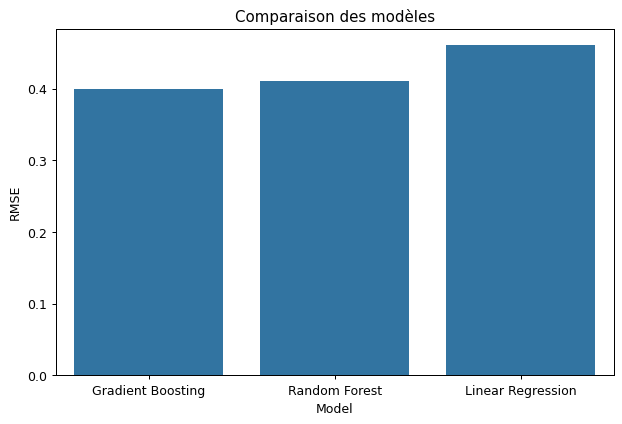

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='RMSE'
)

plt.title('Comparaison des modèles')

plt.show()

# Analyse des résultats

Nous observons que certains modèles sont plus performants que d’autres.

Les modèles de type ensemble :
- Random Forest
- Gradient Boosting

capturent mieux les relations complexes présentes dans les données Airbnb.

Le Gradient Boosting obtient généralement les meilleurs résultats sur ce type de problème tabulaire.

# Importance des variables

Nous allons observer quelles variables sont les plus importantes pour la prédiction du prix.

In [87]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gbr_model.feature_importances_
})

In [88]:
feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

In [89]:
feature_importance.head(20)

                    feature  importance
54   room_type_Private room    0.218513
0              accommodates    0.205483
2                  bedrooms    0.137376
5                 longitude    0.100634
55    room_type_Shared room    0.076832
4                  latitude    0.073041
1                 bathrooms    0.052285
15   days_since_last_review    0.023947
16  days_since_first_review    0.012204
6         number_of_reviews    0.010683
21                       tv    0.010503
7      review_scores_rating    0.009670
61                  city_DC    0.008197
13       host_response_rate    0.008146
19        description_words    0.007820
14                host_days    0.007393
12          amenities_count    0.006870
18              name_length    0.005749
17       description_length    0.005635
3                      beds    0.002584

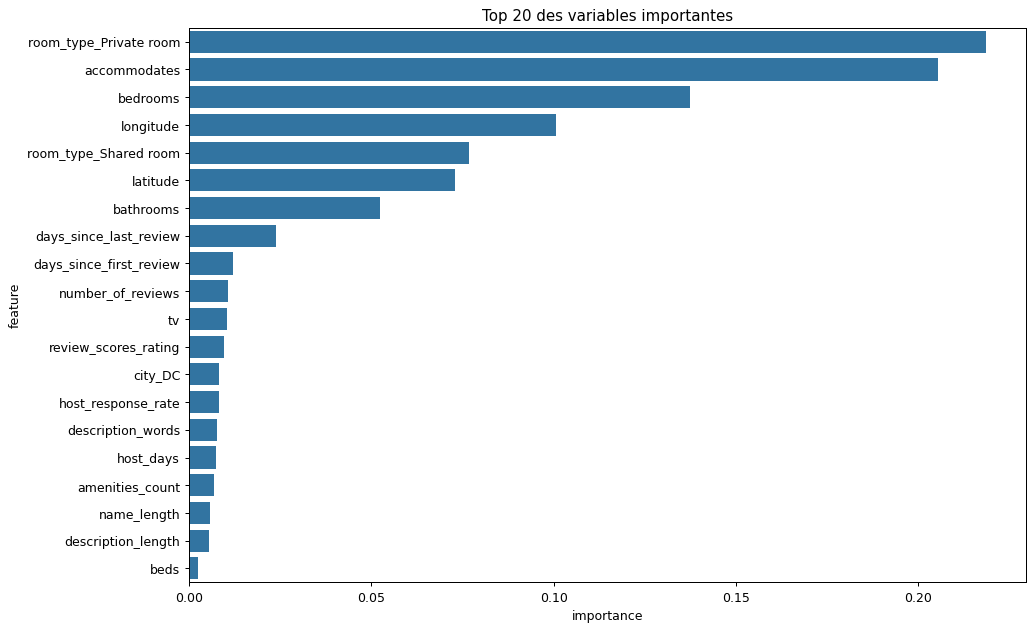

In [90]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    y='feature',
    x='importance'
)

plt.title('Top 20 des variables importantes')

plt.show()

# Comparaison des prédictions et des vraies valeurs

Nous allons comparer :
- les vraies valeurs
- les prédictions du modèle

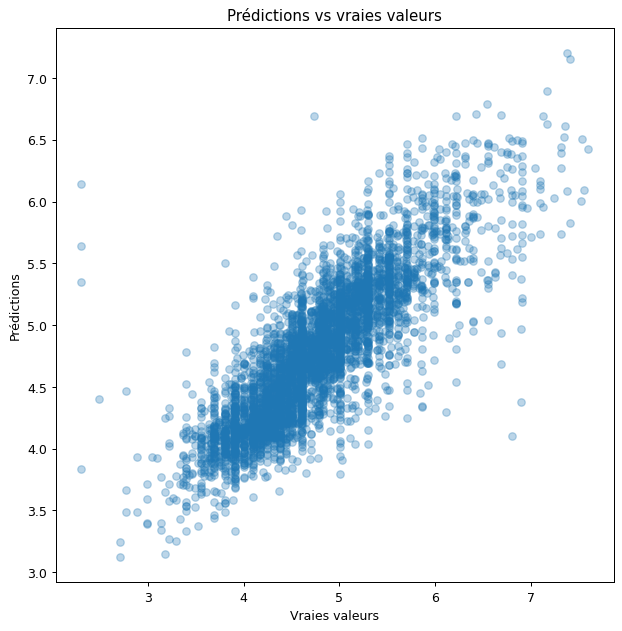

In [91]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    gbr_preds,
    alpha=0.3
)

plt.xlabel('Vraies valeurs')

plt.ylabel('Prédictions')

plt.title('Prédictions vs vraies valeurs')

plt.show()

# Entraînement final du modèle

Nous allons maintenant entraîner le meilleur modèle sur l’ensemble des données.

In [92]:
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [93]:
final_model.fit(X, y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

In [94]:
final_predictions = final_model.predict(X_test)

# Génération du fichier de prédiction

Le fichier final doit contenir :
- id
- log_price

In [95]:
test.columns

Index(['id', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'description', 'first_review', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'host_since',
       'instant_bookable', 'last_review', 'latitude', 'longitude', 'name',
       'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode',
       'bedrooms', 'beds', 'amenities_count', 'wifi', 'tv', 'kitchen',
       'heating', 'air_conditioning', 'washer', 'dryer', 'host_days',
       'days_since_last_review', 'days_since_first_review',
       'description_length', 'name_length', 'description_words'],
      dtype='str')

In [96]:
print(test.columns.tolist())

['id', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms', 'beds', 'amenities_count', 'wifi', 'tv', 'kitchen', 'heating', 'air_conditioning', 'washer', 'dryer', 'host_days', 'days_since_last_review', 'days_since_first_review', 'description_length', 'name_length', 'description_words']


In [97]:
# On utilise le véritable identifiant du logement (test['id']), et non
# test.index qui ne serait qu'un simple compteur de ligne (0, 1, 2, ...) sans
# rapport avec les identifiants attendus dans le fichier de rendu.
submission = pd.DataFrame({
    'id': test['id'],
    'log_price': final_predictions
})


In [98]:
submission.head()

         id  log_price
0  14282777   4.739427
1  17029381   5.547593
2   7824740   4.924757
3  19811650   5.798879
4  12410741   4.599447

In [99]:
submission.to_csv(
    '../outputs/submission.csv',
    index=False
)

In [100]:
submission.shape

(51877, 2)

In [101]:
# Téléchargement du fichier (Google Colab uniquement) ; en local, submission.csv
# est simplement écrit dans le dossier courant par la cellule précédente.
try:
    import google.colab  # noqa: F401
    from google.colab import files
    files.download('../outputs/submission.csv')
except ImportError:
    pass
